In [15]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Fix random seed
tf.random.set_seed(42)

# Load MNIST dataset
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize and reshape
X_train = X_train.reshape(-1, 784) / 255.0
X_test = X_test.reshape(-1, 784) / 255.0

# One-hot encoding
y_train = tf.one_hot(y_train, depth=10)
y_test = tf.one_hot(y_test, depth=10)

# Convert to tensors
X_train = tf.convert_to_tensor(X_train, dtype=tf.float32)
y_train = tf.convert_to_tensor(y_train, dtype=tf.float32)
X_test = tf.convert_to_tensor(X_test, dtype=tf.float32)
y_test = tf.convert_to_tensor(y_test, dtype=tf.float32)

# Network parameters
input_size = 784
hidden_size = 128
output_size = 10
learning_rate = 0.01
epochs = 10

# Initialize weights
W1 = tf.Variable(tf.random.normal([input_size, hidden_size], stddev=0.1))
b1 = tf.Variable(tf.zeros([hidden_size]))

W2 = tf.Variable(tf.random.normal([hidden_size, output_size], stddev=0.1))
b2 = tf.Variable(tf.zeros([output_size]))

print("Initial W1 (first 5 values):")
print(W1.numpy().flatten()[:5])

print("\nInitial W2 (first 5 values):")
print(W2.numpy().flatten()[:5])

# Training loop
batch_size = 128
learning_rate = 0.1
epochs = 10

dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
dataset = dataset.shuffle(60000).batch(batch_size)

loss_history = []
accuracy_history = []
weight_update_history = []
grad_W1_history = []
grad_W2_history = []

for epoch in range(epochs):

    epoch_loss = 0
    correct = 0
    total = 0
    total_grad_W1 = 0
    total_grad_W2 = 0

    old_W1 = W1.numpy()

    for x_batch, y_batch in dataset:

        with tf.GradientTape() as tape:

            # -------- Forward Propagation --------
            Z1 = tf.matmul(x_batch, W1) + b1
            A1 = tf.nn.relu(Z1)

            Z2 = tf.matmul(A1, W2) + b2

            loss = tf.reduce_mean(
                tf.nn.softmax_cross_entropy_with_logits(
                    labels=y_batch,
                    logits=Z2
                )
            )

        # -------- Backpropagation --------
        grads = tape.gradient(loss, [W1, b1, W2, b2])

        total_grad_W1 += tf.norm(grads[0]).numpy()
        total_grad_W2 += tf.norm(grads[2]).numpy()

        W1.assign_sub(learning_rate * grads[0])
        b1.assign_sub(learning_rate * grads[1])
        W2.assign_sub(learning_rate * grads[2])
        b2.assign_sub(learning_rate * grads[3])

        epoch_loss += loss.numpy()

        preds = tf.argmax(Z2, axis=1)
        labels = tf.argmax(y_batch, axis=1)

        correct += tf.reduce_sum(tf.cast(preds == labels, tf.float32)).numpy()
        total += y_batch.shape[0]

    acc = correct / total

    # Save history
    loss_history.append(epoch_loss)
    accuracy_history.append(acc)

    weight_update = np.linalg.norm(W1.numpy() - old_W1)
    weight_update_history.append(weight_update)

    grad_W1_history.append(total_grad_W1)
    grad_W2_history.append(total_grad_W2)

    print(f"Epoch {epoch+1}")
    print(f"Loss: {epoch_loss:.4f}")
    print(f"Accuracy: {acc*100:.2f}%")
    print("-"*40)

print("\nFinal W1 (first 5 values):")
print(W1.numpy().flatten()[:5])

print("\nFinal W2 (first 5 values):")
print(W2.numpy().flatten()[:5])

Initial W1 (first 5 values):
[ 0.03274685 -0.08426258  0.03194337 -0.14075519 -0.238806  ]

Initial W2 (first 5 values):
[ 0.00842246 -0.08609038  0.0378123  -0.00051963 -0.0494532 ]
Epoch 1
Loss: 228.4635
Accuracy: 86.35%
----------------------------------------
Epoch 2
Loss: 126.8887
Accuracy: 92.15%
----------------------------------------
Epoch 3
Loss: 103.3088
Accuracy: 93.69%
----------------------------------------
Epoch 4
Loss: 87.6255
Accuracy: 94.68%
----------------------------------------
Epoch 5
Loss: 76.3560
Accuracy: 95.38%
----------------------------------------
Epoch 6
Loss: 67.8188
Accuracy: 95.80%
----------------------------------------
Epoch 7
Loss: 61.0501
Accuracy: 96.29%
----------------------------------------
Epoch 8
Loss: 55.7331
Accuracy: 96.65%
----------------------------------------
Epoch 9
Loss: 51.0193
Accuracy: 96.92%
----------------------------------------
Epoch 10
Loss: 47.0671
Accuracy: 97.18%
----------------------------------------

Final W1 (fi

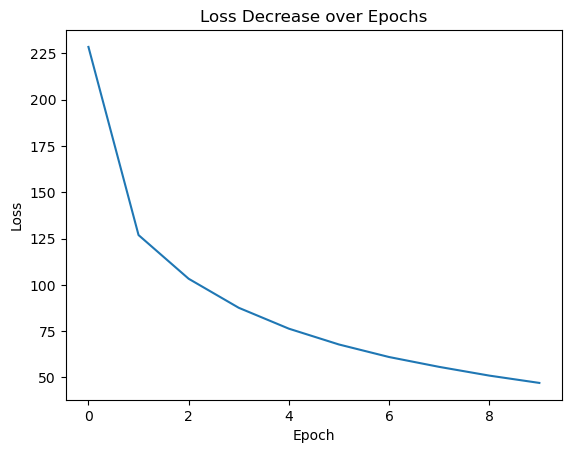

In [16]:
plt.figure()
plt.plot(loss_history)
plt.title("Loss Decrease over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

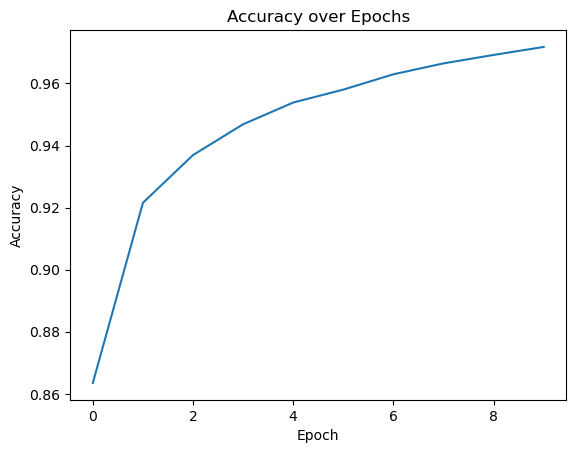

In [17]:
plt.figure()
plt.plot(accuracy_history)
plt.title("Accuracy over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

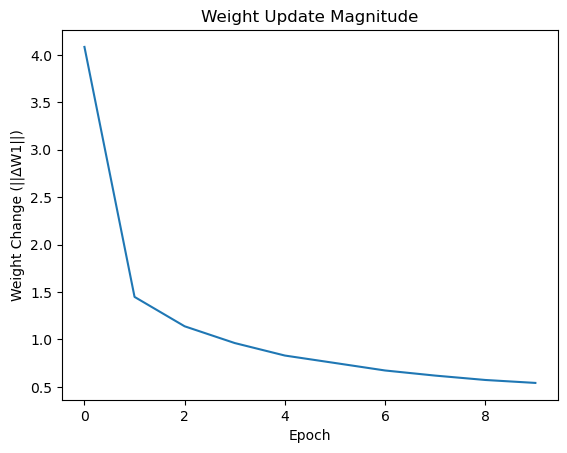

In [18]:
plt.figure()
plt.plot(weight_update_history)
plt.title("Weight Update Magnitude")
plt.xlabel("Epoch")
plt.ylabel("Weight Change (||ΔW1||)")
plt.show()

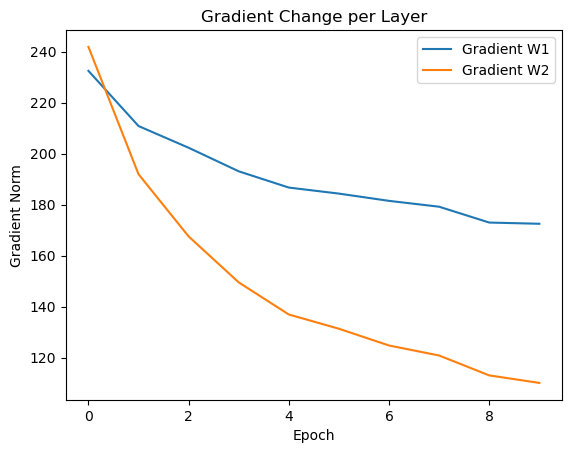

In [19]:
plt.figure()
plt.plot(grad_W1_history, label="Gradient W1")
plt.plot(grad_W2_history, label="Gradient W2")
plt.legend()
plt.title("Gradient Change per Layer")
plt.xlabel("Epoch")
plt.ylabel("Gradient Norm")
plt.show()